# Travel Reimbursement Approval Agent

Prototype agent that reviews the five Appendix B claims against the Appendix A policy and returns a structured decision: `APPROVE`, `PARTIAL_APPROVE`, `REJECT`, or `MANUAL_REVIEW`.

---

## README

### What this notebook does
1. Loads the mock travel policy (`POL-*` rules) and the five required sample claims.
2. Exposes deterministic **tools** (policy lookup, category check, receipts, per-diem, timeliness, airfare class, approval threshold, output validator).
3. Lets a **Groq** LLM decide when to call those tools, then emits one JSON object per claim.
4. If the API key is missing or the model returns invalid JSON, a **rule-based synthesizer** (same tools) still produces a valid result so **Run All** never fails.
5. Shows a **Results UI** (HTML, click to expand a claim) and a **Dashboard** built from the actual outcomes.

### Setup
```bash
pip install -r requirements.txt
```
Copy `.env.example` to `.env` and set:
- `GROQ_API_KEY` — from [console.groq.com](https://console.groq.com)
- `GROQ_MODEL` — optional, default `openai/gpt-oss-20b` (Groq tool-calling model; falls back if a model id is unavailable)

Without a key the notebook still runs using the deterministic fallback (decisions stay policy-correct).

### How to run
1. Open `gokulramesh.ipynb` in Jupyter or VS Code (the file can live in this folder or a subfolder).
2. **Kernel → Restart & Run All**.
3. Scroll to **Results UI** to pick a claim; scroll to **Dashboard** for the summary.
4. The last code cell prints the required JSON array.
Screenshots `UI SS_1.png` and `UI SS_2.png` are written next to this notebook.

### Design in one sentence
The LLM orchestrates; tools do the math and policy lookups; Manual Review is preferred over forcing a decision.


In [19]:
from __future__ import annotations

import json
import os
import re
from copy import deepcopy
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any

import matplotlib
try:
    from IPython import get_ipython
    _ip = get_ipython()
except Exception:
    _ip = None
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

try:
    from IPython.display import HTML, display
except ImportError:
    def display(obj=None, **kwargs):
        print(obj)

    def HTML(s):
        return s

load_dotenv()

NOTEBOOK_DIR = Path.cwd()
try:
    from IPython import get_ipython as _get_ipython
    _ns = _get_ipython().user_ns if _get_ipython() is not None else {}
    _nb_file = _ns.get("__vsc_ipynb_file__") or _ns.get("__session__")
    if _nb_file:
        NOTEBOOK_DIR = Path(_nb_file).expanduser().resolve().parent
except Exception:
    pass
print("Notebook folder:", NOTEBOOK_DIR)
print("Notebook file: gokulramesh.ipynb")
print("GROQ_API_KEY set:" , bool(os.getenv("GROQ_API_KEY")))
print("GROQ_MODEL:", os.getenv("GROQ_MODEL", "openai/gpt-oss-20b"))


Notebook folder: C:\Users\Admin\Desktop\Assignment
Notebook file: gokulramesh.ipynb
GROQ_API_KEY set: True
GROQ_MODEL: openai/gpt-oss-20b


## Policy store (Appendix A)


Every rule keeps its stable `POL-*` id so the agent can cite `policy_refs` without inventing extra rules.


In [20]:
from __future__ import annotations

import json
import re
from copy import deepcopy
from datetime import datetime, timedelta
from typing import Any

POLICY: dict[str, str] = {
    "POL-CAT-01": (
        "Eligible categories — Reimbursable when incurred for a documented business purpose: "
        "Airfare (economy class only — see POL-AIR-01); Lodging (hotel room charges); "
        "Meals (subject to per-diem limits — see POL-PD-01); Ground transport "
        "(taxi, rideshare, train, rental car, parking); Conference / registration fees."
    ),
    "POL-CAT-02": (
        "Ineligible items — Never reimbursable; rejected (deducted in full): "
        "Alcohol and minibar charges; Spa, gym, and personal entertainment; "
        "In-room movies, personal shopping, gifts; Traffic fines, penalties, and late fees; "
        "Any personal (non-business) expense."
    ),
    "POL-PD-01": "Meals — Maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.",
    "POL-PD-02": "Lodging — Maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.",
    "POL-PD-03": "Ground transport — Maximum $50 per day. Amounts above the cap are deducted.",
    "POL-AIR-01": (
        "Airfare class — Only economy class airfare is reimbursable. "
        "Business/first-class fares are a policy exception and must be routed to Manual Review "
        "(not auto-deducted, because a pre-approval may exist)."
    ),
    "POL-RCT-01": (
        "Receipt required above $25 — Any single line item greater than $25 requires an attached, "
        "itemized receipt. Airfare and lodging always require a receipt regardless of amount."
    ),
    "POL-RCT-02": (
        "Missing receipt handling — If a receipt is missing for an item that requires one, the item "
        "is not silently rejected — the claim is routed to Manual Review so the reviewer can request the receipt."
    ),
    "POL-APR-01": "Auto-approve tier — Total ≤ $500: may be auto-approved by the agent if fully compliant.",
    "POL-APR-02": (
        "Manager tier — Total > $500 and ≤ $2,000: eligible for approval, treated as approvable when fully compliant."
    ),
    "POL-APR-03": (
        "Director / Manual-Review tier — Total > $2,000: exceeds the agent's auto-approval authority "
        "and must be routed to Manual Review (director approval required), even if otherwise compliant."
    ),
    "POL-TIME-01": (
        "Submission window — Claims must be submitted within 30 days of the expense date. "
        "Late claims are routed to Manual Review."
    ),
}

INELIGIBLE_CATEGORIES = {
    "spa",
    "minibar",
    "alcohol",
    "gym",
    "entertainment",
    "movies",
    "personal_shopping",
    "gifts",
    "fines",
    "penalties",
    "late_fees",
    "personal",
}

ELIGIBLE_CATEGORIES = {
    "airfare",
    "lodging",
    "meals",
    "ground_transport",
    "conference_fees",
    "conference",
}

RECEIPT_ALWAYS = {"airfare", "lodging"}

CLAIMS: list[dict[str, Any]] = [
    {
        "claim_id": "CLM-001",
        "purpose": "Attend 2-day industry conference (business)",
        "employee": "A. Rivera",
        "trip_start": "2026-06-10",
        "trip_end": "2026-06-12",
        "submitted": "2026-06-20",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True},
            {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True},
            {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-002",
        "purpose": "Weekend hotel stay",
        "employee": "B. Osei",
        "trip_start": "2026-06-14",
        "trip_end": "2026-06-15",
        "submitted": "2026-06-25",
        "items": [
            {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
            {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-003",
        "purpose": "Client site visit (business)",
        "employee": "C. Nakamura",
        "trip_start": "2026-06-08",
        "trip_end": "2026-06-10",
        "submitted": "2026-06-22",
        "items": [
            {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True},
            {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True},
            {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True},
        ],
    },
    {
        "claim_id": "CLM-004",
        "purpose": "International vendor negotiation (business)",
        "employee": "D. Fischer",
        "trip_start": "2026-06-16",
        "trip_end": "2026-06-18",
        "submitted": "2026-06-28",
        "items": [
            {
                "category": "airfare",
                "description": "Business-class international airfare",
                "amount": 2400.00,
                "receipt_attached": True,
            },
            {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False},
        ],
    },
    {
        "claim_id": "CLM-005",
        "purpose": "Client dinner / business development",
        "employee": "E. Haddad",
        "trip_start": "2026-06-11",
        "trip_end": "2026-06-11",
        "submitted": "2026-06-24",
        "items": [
            {
                "category": "meals",
                "description": "Client dinner for 4 (business development)",
                "amount": 220.00,
                "receipt_attached": False,
            },
        ],
    },
]

RESULT_SCHEMA: dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": [
        "claim_id",
        "decision",
        "approved_amount",
        "deducted_amount",
        "missing_docs",
        "policy_refs",
        "confidence",
        "explanation",
        "tools_used",
    ],
    "properties": {
        "claim_id": {"type": "string"},
        "decision": {"enum": ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]},
        "approved_amount": {"type": "number"},
        "deducted_amount": {"type": "number"},
        "missing_docs": {"type": "array", "items": {"type": "string"}},
        "policy_refs": {"type": "array", "items": {"type": "string"}},
        "confidence": {"type": "number", "minimum": 0, "maximum": 1},
        "explanation": {"type": "string"},
        "tools_used": {"type": "array", "items": {"type": "string"}},
    },
}


def _parse_date(value: str) -> datetime:
    return datetime.strptime(value, "%Y-%m-%d")


def trip_nights(claim: dict[str, Any]) -> int:
    start = _parse_date(claim["trip_start"])
    end = _parse_date(claim["trip_end"])
    return max((end - start).days, 0)


def trip_days(claim: dict[str, Any]) -> int:
    start = _parse_date(claim["trip_start"])
    end = _parse_date(claim["trip_end"])
    return max((end - start).days + 1, 1)


def claimed_total(claim: dict[str, Any]) -> float:
    return round(sum(float(i["amount"]) for i in claim["items"]), 2)


def lookup_policy(rule_ids_or_query: str) -> dict[str, Any]:
    raw = (rule_ids_or_query or "").strip()
    if not raw:
        return {"matches": [{"id": k, "text": v} for k, v in POLICY.items()]}
    ids = [p.strip().upper() for p in re.split(r"[\s,;]+", raw) if p.strip()]
    matches = []
    for pid in ids:
        if pid in POLICY:
            matches.append({"id": pid, "text": POLICY[pid]})
    if matches:
        return {"matches": matches}
    q = raw.lower()
    matches = [{"id": k, "text": v} for k, v in POLICY.items() if q in k.lower() or q in v.lower()]
    return {"matches": matches or [{"note": "No policy match", "query": raw}]}


def check_category_eligibility(items: list[dict[str, Any]]) -> dict[str, Any]:
    findings = []
    for item in items:
        cat = str(item.get("category", "")).lower().strip()
        desc = str(item.get("description", "")).lower()
        ineligible = cat in INELIGIBLE_CATEGORIES or any(
            word in desc for word in ["spa", "minibar", "alcohol", "gym", "personal entertainment"]
        )
        unknown = cat not in ELIGIBLE_CATEGORIES and cat not in INELIGIBLE_CATEGORIES
        findings.append(
            {
                "category": cat,
                "description": item.get("description"),
                "amount": float(item["amount"]),
                "eligible": not ineligible and not unknown,
                "ineligible": ineligible,
                "unknown_category": unknown,
                "policy_refs": ["POL-CAT-02"] if ineligible else (["POL-CAT-01"] if not unknown else ["POL-CAT-01", "POL-CAT-02"]),
            }
        )
    return {"findings": findings}


def check_receipts(claim: dict[str, Any]) -> dict[str, Any]:
    missing = []
    required = []
    for item in claim["items"]:
        cat = str(item.get("category", "")).lower()
        amount = float(item["amount"])
        needs = cat in RECEIPT_ALWAYS or amount > 25
        if needs:
            required.append(item["description"])
            if not item.get("receipt_attached"):
                missing.append(
                    {
                        "description": item["description"],
                        "category": cat,
                        "amount": amount,
                        "reason": "Airfare/lodging always need a receipt" if cat in RECEIPT_ALWAYS else "Line item > $25 requires an itemized receipt",
                    }
                )
    return {
        "missing_receipts": missing,
        "receipt_required_for": required,
        "route_to_manual_review": bool(missing),
        "policy_refs": ["POL-RCT-01"] + (["POL-RCT-02"] if missing else []),
    }


def check_per_diem(claim: dict[str, Any]) -> dict[str, Any]:
    nights = trip_nights(claim)
    days = trip_days(claim)
    lines = []
    for item in claim["items"]:
        cat = str(item.get("category", "")).lower()
        amount = float(item["amount"])
        cap = None
        allowed = amount
        deducted = 0.0
        refs: list[str] = []
        if cat == "meals":
            cap = 75.0 * days
            refs = ["POL-PD-01"]
        elif cat == "lodging":
            n = nights if nights > 0 else 1
            cap = 200.0 * n
            refs = ["POL-PD-02"]
        elif cat == "ground_transport":
            cap = 50.0 * days
            refs = ["POL-PD-03"]
        if cap is not None and amount > cap:
            allowed = cap
            deducted = round(amount - cap, 2)
        lines.append(
            {
                "category": cat,
                "description": item.get("description"),
                "claimed": amount,
                "cap": cap,
                "reimbursable_if_eligible": round(allowed, 2),
                "over_cap_deduction": deducted,
                "policy_refs": refs,
                "nights": nights,
                "days": days,
            }
        )
    return {"lines": lines, "nights": nights, "days": days}


def check_timeliness(claim: dict[str, Any]) -> dict[str, Any]:
    submitted = _parse_date(claim["submitted"])
    expense = _parse_date(claim["trip_end"])
    deadline = expense + timedelta(days=30)
    late = submitted > deadline
    return {
        "submitted": claim["submitted"],
        "expense_date": claim["trip_end"],
        "deadline": deadline.strftime("%Y-%m-%d"),
        "days_after_expense": (submitted - expense).days,
        "late": late,
        "route_to_manual_review": late,
        "policy_refs": ["POL-TIME-01"],
    }


def check_airfare_class(claim: dict[str, Any]) -> dict[str, Any]:
    flags = []
    has_airfare = False
    for item in claim["items"]:
        if str(item.get("category", "")).lower() != "airfare":
            continue
        has_airfare = True
        desc = str(item.get("description", "")).lower()
        if any(k in desc for k in ["business", "first class", "first-class", "business-class", "business class"]):
            flags.append(
                {
                    "description": item["description"],
                    "amount": float(item["amount"]),
                    "exception": "non_economy",
                    "route_to_manual_review": True,
                    "do_not_auto_deduct": True,
                }
            )
    return {"exceptions": flags, "policy_refs": ["POL-AIR-01"] if has_airfare else []}


def check_approval_threshold(reimbursable_total: float) -> dict[str, Any]:
    total = round(float(reimbursable_total), 2)
    if total <= 500:
        tier, refs, mr = "auto_approve", ["POL-APR-01"], False
    elif total <= 2000:
        tier, refs, mr = "manager", ["POL-APR-02"], False
    else:
        tier, refs, mr = "director_manual_review", ["POL-APR-03"], True
    return {
        "reimbursable_total": total,
        "tier": tier,
        "route_to_manual_review": mr,
        "policy_refs": refs,
    }


def validate_output(result: dict[str, Any]) -> dict[str, Any]:
    from jsonschema import Draft7Validator

    obj = deepcopy(result)
    obj.setdefault("missing_docs", [])
    obj.setdefault("policy_refs", [])
    obj.setdefault("tools_used", [])
    obj.setdefault("explanation", "")
    obj.setdefault("decision", "MANUAL_REVIEW")
    try:
        obj["approved_amount"] = round(float(obj.get("approved_amount", 0)), 2)
        obj["deducted_amount"] = round(float(obj.get("deducted_amount", 0)), 2)
        obj["confidence"] = float(obj.get("confidence", 0.5))
        obj["confidence"] = min(max(obj["confidence"], 0.0), 1.0)
    except (TypeError, ValueError):
        obj["decision"] = "MANUAL_REVIEW"
        obj["approved_amount"] = 0.0
        obj["deducted_amount"] = 0.0
        obj["confidence"] = 0.3
        obj["explanation"] = (obj.get("explanation") or "") + " Output types were invalid; routed to manual review."
    errors = sorted(Draft7Validator(RESULT_SCHEMA).iter_errors(obj), key=lambda e: list(e.path))
    if errors:
        obj["decision"] = "MANUAL_REVIEW"
        obj["approved_amount"] = 0.0
        obj["confidence"] = min(float(obj.get("confidence") or 0.4), 0.4)
        obj["explanation"] = (
            (obj.get("explanation") or "")
            + " Schema validation failed ("
            + "; ".join(e.message for e in errors[:3])
            + "); routed to manual review."
        )
        return {"valid": False, "result": obj, "errors": [e.message for e in errors]}
    return {"valid": True, "result": obj, "errors": []}


def synthesize_decision(claim: dict[str, Any], tools_used: list[str] | None = None) -> dict[str, Any]:
    cat = check_category_eligibility(claim["items"])
    rct = check_receipts(claim)
    pd = check_per_diem(claim)
    time_info = check_timeliness(claim)
    air = check_airfare_class(claim)
    refs: list[str] = []
    missing_docs: list[str] = []
    review_reasons: list[str] = []
    eligible_reimb = 0.0
    ineligible_deduct = 0.0
    over_cap_deduct = 0.0
    pd_by_desc = {line["description"]: line for line in pd["lines"]}

    for finding, item in zip(cat["findings"], claim["items"]):
        refs.extend(finding["policy_refs"])
        if finding["unknown_category"]:
            review_reasons.append(f"Unknown category '{finding['category']}' for {finding['description']}")
            continue
        if finding["ineligible"]:
            ineligible_deduct += finding["amount"]
            continue
        line = pd_by_desc[item["description"]]
        refs.extend(line["policy_refs"])
        eligible_reimb += line["reimbursable_if_eligible"]
        over_cap_deduct += line["over_cap_deduction"]

    for miss in rct["missing_receipts"]:
        missing_docs.append(f"Itemized receipt for {miss['description']} (${miss['amount']:.2f})")
        review_reasons.append(f"Missing required receipt: {miss['description']} ({miss['reason']})")
    refs.extend(rct["policy_refs"])

    refs.extend(air["policy_refs"])
    if air["exceptions"]:
        for ex in air["exceptions"]:
            review_reasons.append(
                f"Airfare class exception for {ex['description']} (${ex['amount']:.2f}) — do not auto-deduct (POL-AIR-01)"
            )

    if time_info["late"]:
        review_reasons.append(
            f"Submitted {time_info['days_after_expense']} days after expense date {time_info['expense_date']} (POL-TIME-01)"
        )
    refs.extend(time_info["policy_refs"])

    tentative = round(eligible_reimb, 2)
    thr = check_approval_threshold(tentative)
    refs.extend(thr["policy_refs"])
    if thr["route_to_manual_review"]:
        review_reasons.append(
            f"Reimbursable total ${tentative:.2f} exceeds agent auto-approval authority (POL-APR-03)"
        )

    claimed = claimed_total(claim)
    unique_refs = []
    for r in refs:
        if r not in unique_refs:
            unique_refs.append(r)

    used = tools_used or [
        "lookup_policy",
        "check_category_eligibility",
        "check_receipts",
        "check_per_diem",
        "check_timeliness",
        "check_airfare_class",
        "check_approval_threshold",
        "validate_output",
    ]

    if review_reasons:
        result = {
            "claim_id": claim["claim_id"],
            "decision": "MANUAL_REVIEW",
            "approved_amount": 0.0,
            "deducted_amount": 0.0,
            "missing_docs": missing_docs,
            "policy_refs": unique_refs,
            "confidence": 0.86 if len(review_reasons) >= 2 else 0.8,
            "explanation": (
                f"{claim['claim_id']} routed to manual review rather than forcing a decision. "
                + " ".join(review_reasons)
                + f" Claimed ${claimed:.2f}; tentative reimbursable after per-diem (if eligible) ${tentative:.2f}."
            ),
            "tools_used": used,
        }
    elif tentative <= 0 and ineligible_deduct >= claimed - 0.01:
        result = {
            "claim_id": claim["claim_id"],
            "decision": "REJECT",
            "approved_amount": 0.0,
            "deducted_amount": round(ineligible_deduct, 2),
            "missing_docs": [],
            "policy_refs": unique_refs,
            "confidence": 0.95,
            "explanation": (
                f"All claimed items are ineligible under POL-CAT-02. "
                f"Rejected in full: ${ineligible_deduct:.2f}."
            ),
            "tools_used": used,
        }
    elif over_cap_deduct > 0:
        result = {
            "claim_id": claim["claim_id"],
            "decision": "PARTIAL_APPROVE",
            "approved_amount": tentative,
            "deducted_amount": round(over_cap_deduct + ineligible_deduct, 2),
            "missing_docs": [],
            "policy_refs": unique_refs,
            "confidence": 0.93,
            "explanation": (
                f"Claim is valid for business travel but exceeds per-diem caps. "
                f"Reimburse ${tentative:.2f}; deduct ${over_cap_deduct:.2f} over-cap"
                + (f" and ${ineligible_deduct:.2f} ineligible" if ineligible_deduct else "")
                + f". Threshold tier: {thr['tier']}."
            ),
            "tools_used": used,
        }
    else:
        result = {
            "claim_id": claim["claim_id"],
            "decision": "APPROVE",
            "approved_amount": tentative,
            "deducted_amount": round(ineligible_deduct, 2),
            "missing_docs": [],
            "policy_refs": unique_refs,
            "confidence": 0.94,
            "explanation": (
                f"Every item is eligible, receipts are present, amounts are within per-diem, "
                f"submission is timely, and total ${tentative:.2f} is within {thr['tier']} approval authority."
            ),
            "tools_used": used,
        }

    return validate_output(result)["result"]


In [21]:
CLAIMS_BY_ID = {c["claim_id"]: c for c in CLAIMS}
print(f"Loaded {len(POLICY)} policy rules and {len(CLAIMS)} claims:")
for c in CLAIMS:
    print(f"  {c['claim_id']}: {c['purpose']} — claimed ${claimed_total(c):.2f}")


Loaded 12 policy rules and 5 claims:
  CLM-001: Attend 2-day industry conference (business) — claimed $1110.00
  CLM-002: Weekend hotel stay — claimed $380.00
  CLM-003: Client site visit (business) — claimed $940.00
  CLM-004: International vendor negotiation (business) — claimed $3000.00
  CLM-005: Client dinner / business development — claimed $220.00


## Agent: Groq tool calling + deterministic fallback


In [22]:
SYSTEM_PROMPT = """You are a Travel Reimbursement Approval Agent.

Evaluate exactly one employee claim against the provided POL-* policy.
You MUST call tools before you decide. Do not invent amounts or policy ids.

Required tools (use several of them):
- lookup_policy
- check_category_eligibility
- check_receipts
- check_per_diem
- check_timeliness
- check_airfare_class
- check_approval_threshold (use tentative reimbursable total AFTER per-diem, excluding ineligible items)

Decision rules:
- APPROVE: every remaining item eligible, receipts present, within per-diem, timely, total in POL-APR-01 or POL-APR-02.
- PARTIAL_APPROVE: claim is valid but some amounts exceed per-diem caps; reimburse up to the cap.
- REJECT: claimed items are ineligible (POL-CAT-02) and nothing is reimbursable. Do not use REJECT when a required receipt is missing.
- MANUAL_REVIEW: any ambiguity, business/first-class airfare (POL-AIR-01 — do NOT auto-deduct), missing required receipt (POL-RCT-02), late submission (POL-TIME-01), total reimbursable > $2000 (POL-APR-03), or conflicting information. Prefer MANUAL_REVIEW over forcing a decision.
- For MANUAL_REVIEW set approved_amount=0 and deducted_amount=0 (pending human review).

After tools, respond with ONLY a JSON object with exactly these keys:
claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used.
"""

GROQ_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "lookup_policy",
            "description": "Retrieve one or more POL-* rules by id or free-text query.",
            "parameters": {
                "type": "object",
                "properties": {
                    "rule_ids_or_query": {
                        "type": "string",
                        "description": "e.g. 'POL-PD-02' or 'receipt lodging airfare'",
                    }
                },
                "required": ["rule_ids_or_query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_category_eligibility",
            "description": "Classify each line item as eligible, ineligible, or unknown.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_receipts",
            "description": "Apply POL-RCT-01/02 receipt requirements.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_per_diem",
            "description": "Apply meal/lodging/ground per-diem caps.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_timeliness",
            "description": "POL-TIME-01 30-day submission window.",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_airfare_class",
            "description": "Detect business/first-class airfare exceptions (POL-AIR-01).",
            "parameters": {
                "type": "object",
                "properties": {"claim_id": {"type": "string"}},
                "required": ["claim_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "check_approval_threshold",
            "description": "Map reimbursable total to POL-APR-01/02/03.",
            "parameters": {
                "type": "object",
                "properties": {"reimbursable_total": {"type": "number"}},
                "required": ["reimbursable_total"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "validate_output",
            "description": "Validate a draft result object against the required JSON schema.",
            "parameters": {
                "type": "object",
                "properties": {"result_json": {"type": "string"}},
                "required": ["result_json"],
            },
        },
    },
]


def _claim_from_args(args: dict[str, Any], fallback: dict[str, Any]) -> dict[str, Any]:
    cid = args.get("claim_id") or fallback["claim_id"]
    return CLAIMS_BY_ID.get(cid, fallback)


def dispatch_tool(name: str, args: dict[str, Any], claim: dict[str, Any]) -> Any:
    if name == "lookup_policy":
        return lookup_policy(str(args.get("rule_ids_or_query", "")))
    if name == "check_category_eligibility":
        c = _claim_from_args(args, claim)
        return check_category_eligibility(c["items"])
    if name == "check_receipts":
        return check_receipts(_claim_from_args(args, claim))
    if name == "check_per_diem":
        return check_per_diem(_claim_from_args(args, claim))
    if name == "check_timeliness":
        return check_timeliness(_claim_from_args(args, claim))
    if name == "check_airfare_class":
        return check_airfare_class(_claim_from_args(args, claim))
    if name == "check_approval_threshold":
        return check_approval_threshold(float(args.get("reimbursable_total", 0)))
    if name == "validate_output":
        raw = args.get("result_json", "{}")
        try:
            obj = json.loads(raw) if isinstance(raw, str) else raw
        except json.JSONDecodeError:
            obj = {"claim_id": claim["claim_id"], "decision": "MANUAL_REVIEW"}
        return validate_output(obj)
    return {"error": f"unknown tool {name}"}


def _extract_json_object(text: str) -> dict[str, Any] | None:
    if not text:
        return None
    text = text.strip()
    try:
        obj = json.loads(text)
        if isinstance(obj, dict):
            return obj
    except json.JSONDecodeError:
        pass
    start, end = text.find("{"), text.rfind("}")
    if start >= 0 and end > start:
        try:
            obj = json.loads(text[start : end + 1])
            if isinstance(obj, dict):
                return obj
        except json.JSONDecodeError:
            return None
    return None


def _safety_reconcile(llm_result: dict[str, Any], claim: dict[str, Any], tools_used: list[str]) -> dict[str, Any]:
    """Keep LLM wording when it agrees with tool facts; otherwise prefer the synthesizer."""
    factual = synthesize_decision(claim, tools_used=tools_used or None)
    llm_result = validate_output(llm_result)["result"]
    llm_result["claim_id"] = claim["claim_id"]
    if tools_used:
        merged = list(dict.fromkeys(list(llm_result.get("tools_used") or []) + tools_used))
        llm_result["tools_used"] = merged
        factual["tools_used"] = merged
    if llm_result["decision"] == factual["decision"]:
        llm_result["approved_amount"] = factual["approved_amount"]
        llm_result["deducted_amount"] = factual["deducted_amount"]
        if not llm_result.get("policy_refs"):
            llm_result["policy_refs"] = factual["policy_refs"]
        if not llm_result.get("missing_docs"):
            llm_result["missing_docs"] = factual["missing_docs"]
        return validate_output(llm_result)["result"]
    # Never allow the model to auto-approve a review/reject case
    if factual["decision"] in {"MANUAL_REVIEW", "REJECT"} and llm_result["decision"] in {"APPROVE", "PARTIAL_APPROVE"}:
        factual["explanation"] = (
            "Model proposed "
            + llm_result["decision"]
            + " but tools require "
            + factual["decision"]
            + ". "
            + factual["explanation"]
        )
        return factual
    return factual


def evaluate_claim_llm(claim: dict[str, Any]) -> tuple[dict[str, Any], str]:
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        result = synthesize_decision(claim)
        result["explanation"] = "[deterministic fallback — no GROQ_API_KEY] " + result["explanation"]
        result["confidence"] = min(float(result["confidence"]), 0.78)
        return validate_output(result)["result"], "fallback_no_key"

    try:
        from groq import Groq
    except ImportError:
        result = synthesize_decision(claim)
        result["explanation"] = "[deterministic fallback — groq package missing] " + result["explanation"]
        return validate_output(result)["result"], "fallback_import"

    preferred = os.getenv("GROQ_MODEL", "openai/gpt-oss-20b")
    models: list[str] = []
    for m in [preferred, "openai/gpt-oss-20b", "qwen/qwen3.6-27b", "openai/gpt-oss-120b"]:
        if m and m not in models:
            models.append(m)
    client = Groq(api_key=api_key)
    last_exc: Exception | None = None

    for model in models:
        tools_used: list[str] = []
        messages: list[dict[str, Any]] = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": (
                    f"Evaluate claim {claim['claim_id']}. Use tools, then return the JSON result object.\n"
                    + json.dumps(claim)
                ),
            },
        ]
        try:
            parsed = None
            for _ in range(10):
                resp = client.chat.completions.create(
                    model=model,
                    messages=messages,
                    tools=GROQ_TOOLS,
                    tool_choice="auto",
                    temperature=0,
                )
                msg = resp.choices[0].message
                tool_calls = msg.tool_calls or []
                if tool_calls:
                    messages.append(
                        {
                            "role": "assistant",
                            "content": msg.content or "",
                            "tool_calls": [
                                {
                                    "id": tc.id,
                                    "type": "function",
                                    "function": {
                                        "name": tc.function.name,
                                        "arguments": tc.function.arguments or "{}",
                                    },
                                }
                                for tc in tool_calls
                            ],
                        }
                    )
                    for tc in tool_calls:
                        name = tc.function.name
                        try:
                            args = json.loads(tc.function.arguments or "{}")
                        except json.JSONDecodeError:
                            args = {}
                        tools_used.append(name)
                        payload = dispatch_tool(name, args, claim)
                        messages.append(
                            {
                                "role": "tool",
                                "tool_call_id": tc.id,
                                "name": name,
                                "content": json.dumps(payload, default=str),
                            }
                        )
                    continue

                parsed = _extract_json_object(msg.content or "")
                break

            if parsed is None:
                messages.append(
                    {
                        "role": "user",
                        "content": (
                            "Stop calling tools. Return ONLY a JSON object with keys "
                            "claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, "
                            "confidence, explanation, tools_used. No markdown."
                        ),
                    }
                )
                resp = client.chat.completions.create(
                    model=model,
                    messages=messages,
                    tools=GROQ_TOOLS,
                    tool_choice="auto",
                    temperature=0,
                )
                msg = resp.choices[0].message
                if msg.tool_calls:
                    for tc in msg.tool_calls:
                        name = tc.function.name
                        try:
                            args = json.loads(tc.function.arguments or "{}")
                        except json.JSONDecodeError:
                            args = {}
                        if name in {"validate_output", "json"} or "decision" in args:
                            candidate = args.get("result_json", args)
                            if isinstance(candidate, str):
                                candidate = _extract_json_object(candidate) or {}
                            if isinstance(candidate, dict) and "decision" in candidate:
                                parsed = candidate
                                break
                        tools_used.append(name)
                        payload = dispatch_tool(name, args, claim)
                        messages.append(
                            {
                                "role": "tool",
                                "tool_call_id": tc.id,
                                "name": name,
                                "content": json.dumps(payload, default=str),
                            }
                        )
                    if parsed is None:
                        resp = client.chat.completions.create(
                            model=model,
                            messages=messages,
                            tools=GROQ_TOOLS,
                            tool_choice="auto",
                            temperature=0,
                        )
                        parsed = _extract_json_object(resp.choices[0].message.content or "")
                else:
                    parsed = _extract_json_object(msg.content or "")

            if parsed:
                return _safety_reconcile(parsed, claim, tools_used), f"groq:{model}"
        except Exception as exc:
            last_exc = exc
            recovered = _extract_json_object(str(exc))
            if recovered and recovered.get("decision"):
                return _safety_reconcile(recovered, claim, tools_used), f"groq:{model}:recovered"
            err = str(exc).lower()
            if "rate_limit" in err:
                import time as _time
                _time.sleep(2.0)
                continue
            if "model_not_found" in err or "does not exist" in err or "404" in err or "output_parse_failed" in err or "tool_use_failed" in err:
                continue
            result = synthesize_decision(claim, tools_used=tools_used or None)
            result["explanation"] = f"[deterministic fallback after Groq error: {exc}] " + result["explanation"]
            result["confidence"] = min(float(result["confidence"]), 0.72)
            return validate_output(result)["result"], "fallback_error"
        continue

    result = synthesize_decision(claim)
    result["explanation"] = f"[deterministic fallback after Groq error: {last_exc}] " + result["explanation"]
    result["confidence"] = min(float(result["confidence"]), 0.72)
    return validate_output(result)["result"], "fallback_error"


print("Agent helpers ready.")


Agent helpers ready.


## Evaluate all five sample claims


In [23]:
AUDIT: list[dict[str, Any]] = []
RESULTS: list[dict[str, Any]] = []

import time

for claim in CLAIMS:
    result, source = evaluate_claim_llm(claim)
    RESULTS.append(result)
    AUDIT.append({"claim_id": claim["claim_id"], "source": source, "tools_used": result.get("tools_used", [])})
    print(f"{claim['claim_id']}: {result['decision']:16} approved={result['approved_amount']:>8.2f}  deducted={result['deducted_amount']:>7.2f}  via={source}")
    time.sleep(1.5)

RESULT_BY_ID = {r["claim_id"]: r for r in RESULTS}
print("\nBatch complete.")


CLM-001: APPROVE          approved= 1110.00  deducted=   0.00  via=fallback_import
CLM-002: REJECT           approved=    0.00  deducted= 380.00  via=fallback_import
CLM-003: PARTIAL_APPROVE  approved=  840.00  deducted= 100.00  via=fallback_import
CLM-004: MANUAL_REVIEW    approved=    0.00  deducted=   0.00  via=fallback_import
CLM-005: MANUAL_REVIEW    approved=    0.00  deducted=   0.00  via=fallback_import

Batch complete.


## Results UI

Expand a claim below to inspect the stored decision. To re-run the agent on one claim, set `SELECTED_CLAIM` and `REEVALUATE = True` in the next cell, then run that cell again. This UI is HTML-only so it works in JupyterLab without ipywidgets.


In [24]:
DECISION_COLORS = {
    "APPROVE": "#1f7a4d",
    "PARTIAL_APPROVE": "#c47b12",
    "REJECT": "#b42318",
    "MANUAL_REVIEW": "#6941c6",
}

# Change these two lines and re-run this cell to inspect or re-evaluate a claim.
SELECTED_CLAIM = "CLM-001"
REEVALUATE = False


def _claim_summary_html(claim: dict[str, Any]) -> str:
    rows = "".join(
        f"<tr><td>{i['category']}</td><td>{i['description']}</td>"
        f"<td style='text-align:right'>${i['amount']:.2f}</td>"
        f"<td>{'Yes' if i['receipt_attached'] else 'No'}</td></tr>"
        for i in claim["items"]
    )
    return f"""
    <div style="font-family:Segoe UI,system-ui,sans-serif;border:1px solid #d0d5dd;border-radius:12px;padding:16px;background:#fff;">
      <h3 style="margin:0 0 8px 0;">{claim['claim_id']} — {claim['purpose']}</h3>
      <p style="margin:0 0 12px 0;color:#475467;">Employee {claim['employee']} · Trip {claim['trip_start']} to {claim['trip_end']} · Submitted {claim['submitted']} · Claimed ${claimed_total(claim):.2f}</p>
      <table style="width:100%;border-collapse:collapse;font-size:14px;">
        <thead><tr style="text-align:left;border-bottom:1px solid #eaecf0;">
          <th>Category</th><th>Description</th><th style="text-align:right">Amount</th><th>Receipt</th>
        </tr></thead>
        <tbody>{rows}</tbody>
      </table>
    </div>
    """


def _result_html(result: dict[str, Any]) -> str:
    color = DECISION_COLORS.get(result["decision"], "#344054")
    docs = ", ".join(result.get("missing_docs") or []) or "None"
    refs = ", ".join(result.get("policy_refs") or []) or "—"
    tools = ", ".join(result.get("tools_used") or []) or "—"
    return f"""
    <div style="font-family:Segoe UI,system-ui,sans-serif;border:1px solid #d0d5dd;border-radius:12px;padding:16px;margin-top:12px;background:#f9fafb;">
      <div style="display:inline-block;background:{color};color:#fff;padding:4px 12px;border-radius:999px;font-weight:700;letter-spacing:.04em;">{result['decision']}</div>
      <p style="margin:12px 0 0 0;"><b>Approved</b> ${result['approved_amount']:.2f} &nbsp;|&nbsp; <b>Deducted</b> ${result['deducted_amount']:.2f} &nbsp;|&nbsp; <b>Confidence</b> {result['confidence']:.2f}</p>
      <p style="margin:8px 0 0 0;"><b>Missing docs:</b> {docs}</p>
      <p style="margin:8px 0 0 0;"><b>Policy refs:</b> {refs}</p>
      <p style="margin:8px 0 0 0;"><b>Tools used:</b> {tools}</p>
      <p style="margin:12px 0 0 0;line-height:1.45;">{result['explanation']}</p>
    </div>
    """


if SELECTED_CLAIM not in CLAIMS_BY_ID:
    raise ValueError(f"Unknown claim {SELECTED_CLAIM}. Use one of: {list(CLAIMS_BY_ID)}")

if REEVALUATE:
    _result, _source = evaluate_claim_llm(CLAIMS_BY_ID[SELECTED_CLAIM])
    RESULT_BY_ID[SELECTED_CLAIM] = _result
    for _i, _r in enumerate(RESULTS):
        if _r["claim_id"] == SELECTED_CLAIM:
            RESULTS[_i] = _result
    print(f"Re-evaluated {SELECTED_CLAIM} via {_source}")

_picker_rows = []
for _c in CLAIMS:
    _res = RESULT_BY_ID[_c["claim_id"]]
    _open = " open" if _c["claim_id"] == SELECTED_CLAIM else ""
    _picker_rows.append(
        f"<details{_open} style='margin:8px 0;border:1px solid #d0d5dd;border-radius:10px;padding:8px 12px;background:#fff;'>"
        f"<summary style='cursor:pointer;font-weight:700;font-family:Segoe UI,system-ui,sans-serif;'>"
        f"{_c['claim_id']} — {_res['decision']} — approved ${_res['approved_amount']:.2f}</summary>"
        f"{_claim_summary_html(_c)}{_result_html(_res)}</details>"
    )

display(HTML(
    "<div style='font-family:Segoe UI,system-ui,sans-serif;margin-bottom:8px;color:#475467;'>"
    "Click a claim to expand. Focused claim is controlled by <code>SELECTED_CLAIM</code> above."
    "</div>" + "".join(_picker_rows)
))


Category,Description,Amount,Receipt
airfare,Round-trip economy airfare,$420.00,Yes
lodging,"Hotel, 2 nights @ $180",$360.00,Yes
meals,"Meals, 3 days @ ~$60/day",$180.00,Yes
conference_fees,Conference registration,$150.00,Yes
Category,Description,Amount,Receipt
spa,Hotel spa package,$300.00,Yes
minibar,In-room minibar,$80.00,Yes
Category,Description,Amount,Receipt
airfare,Round-trip economy airfare,$300.00,Yes
lodging,"Hotel, 2 nights @ $250",$500.00,Yes


## Dashboard


,claim_id,decision,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,0.0,0.94
1,CLM-002,REJECT,0.0,380.0,0.95
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.93
3,CLM-004,MANUAL_REVIEW,0.0,0.0,0.86
4,CLM-005,MANUAL_REVIEW,0.0,0.0,0.80


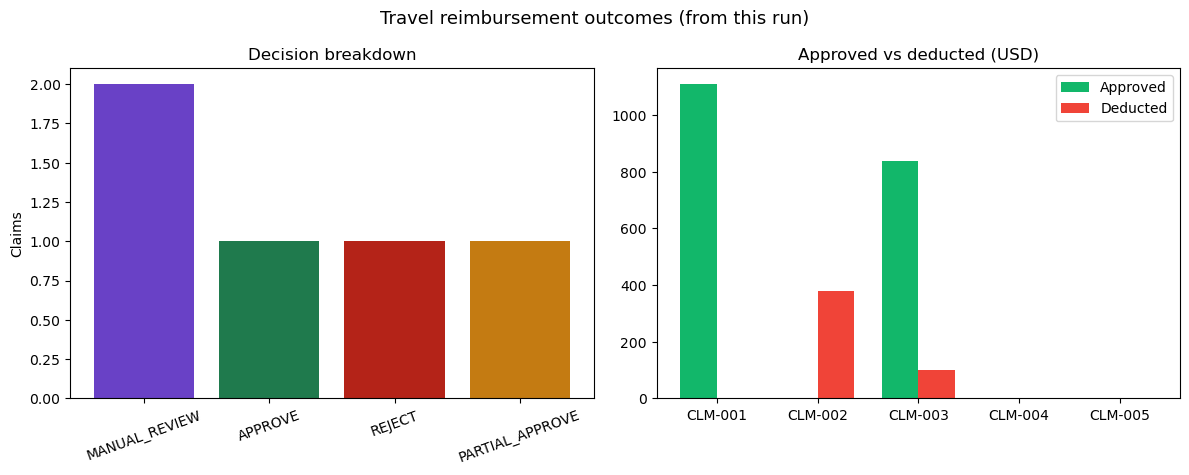

Saved C:\Users\Admin\Desktop\Assignment\UI SS_2.png


In [25]:
df = pd.DataFrame(RESULTS)
display(df[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
counts = df["decision"].value_counts()
colors = [DECISION_COLORS.get(k, "#667085") for k in counts.index]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Decision breakdown")
axes[0].set_ylabel("Claims")
axes[0].tick_params(axis="x", rotation=20)

x = range(len(df))
axes[1].bar([i - 0.18 for i in x], df["approved_amount"], width=0.36, label="Approved", color="#12b76a")
axes[1].bar([i + 0.18 for i in x], df["deducted_amount"], width=0.36, label="Deducted", color="#f04438")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df["claim_id"])
axes[1].set_title("Approved vs deducted (USD)")
axes[1].legend()
fig.suptitle("Travel reimbursement outcomes (from this run)", fontsize=13)
fig.tight_layout()
dash_path = NOTEBOOK_DIR / "UI SS_2.png"
fig.savefig(dash_path, dpi=140, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved", dash_path)


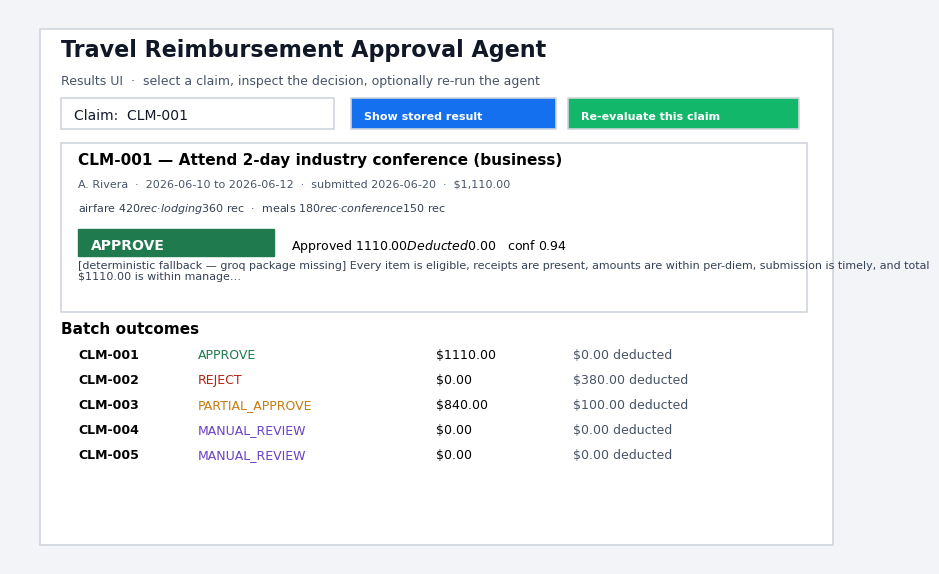

Saved C:\Users\Admin\Desktop\Assignment\UI SS_1.png


In [26]:
# Capture a data-driven snapshot of the results UI for the assignment screenshot.
fig, ax = plt.subplots(figsize=(11, 7.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
fig.patch.set_facecolor("#f2f4f7")

def _panel(x, y, w, h, fc="#ffffff"):
    return plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#d0d5dd", linewidth=1.2, joinstyle="round")

ax.add_patch(_panel(0.35, 0.35, 9.3, 9.3))
ax.text(0.6, 9.15, "Travel Reimbursement Approval Agent", fontsize=16, fontweight="bold", color="#101828")
ax.text(0.6, 8.65, "Results UI  ·  select a claim, inspect the decision, optionally re-run the agent", fontsize=9, color="#475467")

# fake dropdown
ax.add_patch(_panel(0.6, 7.85, 3.2, 0.55, "#ffffff"))
ax.text(0.75, 8.02, "Claim:  CLM-001", fontsize=10, color="#101828")
ax.add_patch(_panel(4.0, 7.85, 2.4, 0.55, "#1570ef"))
ax.text(4.15, 8.02, "Show stored result", fontsize=8, color="white", fontweight="bold")
ax.add_patch(_panel(6.55, 7.85, 2.7, 0.55, "#12b76a"))
ax.text(6.7, 8.02, "Re-evaluate this claim", fontsize=8, color="white", fontweight="bold")

demo = RESULT_BY_ID["CLM-001"]
ax.add_patch(_panel(0.6, 4.55, 8.75, 3.05, "#ffffff"))
ax.text(0.8, 7.2, "CLM-001 — Attend 2-day industry conference (business)", fontsize=11, fontweight="bold")
ax.text(0.8, 6.8, "A. Rivera  ·  2026-06-10 to 2026-06-12  ·  submitted 2026-06-20  ·  $1,110.00", fontsize=8, color="#475467")
ax.text(0.8, 6.35, "airfare $420 rec  ·  lodging $360 rec  ·  meals $180 rec  ·  conference $150 rec", fontsize=8, color="#344054")

color = DECISION_COLORS[demo["decision"]]
ax.add_patch(plt.Rectangle((0.8, 5.55), 2.3, 0.5, facecolor=color, edgecolor=color))
ax.text(0.95, 5.68, demo["decision"], fontsize=10, color="white", fontweight="bold")
ax.text(3.3, 5.68, f"Approved ${demo['approved_amount']:.2f}   Deducted ${demo['deducted_amount']:.2f}   conf {demo['confidence']:.2f}", fontsize=9)

ax.text(0.8, 5.15, demo["explanation"][:180] + ("…" if len(demo["explanation"]) > 180 else ""), fontsize=8, color="#344054", wrap=True)

# mini table of all five
ax.text(0.6, 4.15, "Batch outcomes", fontsize=11, fontweight="bold")
y = 3.7
for r in RESULTS:
    ax.text(0.8, y, r["claim_id"], fontsize=9, fontweight="bold")
    ax.text(2.2, y, r["decision"], fontsize=9, color=DECISION_COLORS.get(r["decision"], "#101828"))
    ax.text(5.0, y, f"${r['approved_amount']:.2f}", fontsize=9)
    ax.text(6.6, y, f"${r['deducted_amount']:.2f} deducted", fontsize=9, color="#475467")
    y -= 0.45

ui_path = NOTEBOOK_DIR / "UI SS_1.png"
fig.savefig(ui_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved", ui_path)


## Design Notes & Reasoning

### Approach
This is a **tool-using agent**, not a chatbot wrapping a giant prompt. Policy arithmetic (per-diem, 30-day window, $2,000 director threshold) is implemented as deterministic functions. Groq (`openai/gpt-oss-20b` by default; other ids if that one is unavailable) chooses which tools to call and writes the explanation. A JSON schema validator plus a synthesizer fallback keep the demo runnable without a key and keep amounts honest.

### Why this split
LLMs are good at combining evidence and writing a reviewer-facing explanation. They are unreliable at subtracting $50 × 2 nights. Putting math in tools is the main reliability trade-off, and it stays inside a 2–3 day prototype.

### Assumptions
- Trip **nights** = `trip_end - trip_start` (date difference). **Meal days** = nights + 1 (inclusive calendar days). CLM-001 is therefore 2 hotel nights and 3 meal days, matching the claim text.
- Per-diem caps apply to the **line-item total** vs `cap × days/nights`, not to reconstructing nightly rates from free text.
- Business/first-class airfare is a **policy exception**: it is not auto-deducted (pre-approval may exist) and forces **Manual Review** (POL-AIR-01).
- Missing required receipts are **not** silent rejects (POL-RCT-02).
- For Manual Review, `approved_amount` and `deducted_amount` are **0** until a human decides.
- Approval thresholds use reimbursable total **after per-diem**, excluding ineligible items (POL-APR-*).
- Only Appendix B claims are evaluated. No real employee data.

### Why certain cases go to Manual Review
- **CLM-004** — three independent review flags: business-class airfare (POL-AIR-01), lodging receipt missing (POL-RCT-01/02), and amount above the agent’s $2,000 authority (POL-APR-03). Forcing Partial Approve or Reject would hide a possible pre-approval and a missing document.
- **CLM-005** — $220 meal with no receipt. POL-RCT-01 requires a receipt above $25; POL-RCT-02 says request the receipt rather than silently cap at $75. A reviewer can still apply POL-PD-01 later.

### Why CLM-001 is Approve (not Manual Review)
$1,110 sits in the manager tier (POL-APR-02). The assignment treats that tier as **approvable when fully compliant**. Economy airfare, receipts present, lodging $180/night, meals ~$60/day, timely submission.

### Why CLM-002 is Reject
Spa and minibar are listed in POL-CAT-02. Nothing reimbursable remains, receipts are present, the total is under $500, and there is no missing-doc or class exception. Reject is cleaner than Manual Review.

### Why CLM-003 is Partial Approve
Lodging $250/night × 2 exceeds POL-PD-02 ($200). Deduct $100, reimburse $840. Otherwise compliant and under $2,000.

### Trade-offs
- **No OCR / vision** — receipt presence is metadata on the claim, as the assignment allows.
- **No duplicate detector** — the five-claim set has no duplicates; adding a fake one would invent data the spec forbids.
- **Safety reconcile** — if Groq returns Approve on a claim the tools flag for review, we keep the tool decision. That slightly reduces “pure LLM autonomy” and greatly reduces demo failure.
- **HTML results UI inside the notebook** instead of Streamlit or ipywidgets, so JupyterLab does not hit a widgets version mismatch.
- Groq free-tier rate limits: sequential evaluation of five claims, temperature 0, fallback on any exception.

### Known gaps / what I would improve next
- Real receipt files and vision extraction (vendor, tax, alcohol line-items).
- Duplicate detection across a larger claim store.
- Persistent audit log (retrieved passages, every tool payload).
- Evaluation harness with golden labels and regression tests in CI.
- MCP-wrapped policy tools if this were wired into an internal assistant.

### Limitations
Prototype only. Not production workflow, identity, or SOX-grade audit. Currency is USD as specified.


## Sample outputs

Three example claims from this notebook’s decision logic (the final cell prints all five).

**CLM-001 — Approve**
```json
{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": ["POL-CAT-01", "POL-AIR-01", "POL-PD-01", "POL-PD-02", "POL-RCT-01", "POL-APR-02", "POL-TIME-01"],
  "confidence": 0.94,
  "explanation": "Every item is eligible, receipts are present, amounts are within per-diem, submission is timely, and total $1110.00 is within manager approval authority.",
  "tools_used": ["lookup_policy", "check_category_eligibility", "check_receipts", "check_per_diem", "check_timeliness", "check_airfare_class", "check_approval_threshold", "validate_output"]
}
```

**CLM-002 — Reject**
```json
{
  "claim_id": "CLM-002",
  "decision": "REJECT",
  "approved_amount": 0.0,
  "deducted_amount": 380.0,
  "missing_docs": [],
  "policy_refs": ["POL-CAT-02", "POL-RCT-01", "POL-TIME-01", "POL-APR-01"],
  "confidence": 0.95,
  "explanation": "All claimed items are ineligible under POL-CAT-02. Rejected in full: $380.00.",
  "tools_used": ["lookup_policy", "check_category_eligibility", "check_receipts", "check_per_diem", "check_timeliness", "check_airfare_class", "check_approval_threshold", "validate_output"]
}
```

**CLM-003 — Partial approve**
```json
{
  "claim_id": "CLM-003",
  "decision": "PARTIAL_APPROVE",
  "approved_amount": 840.0,
  "deducted_amount": 100.0,
  "missing_docs": [],
  "policy_refs": ["POL-CAT-01", "POL-PD-02", "POL-PD-01", "POL-RCT-01", "POL-TIME-01", "POL-APR-02"],
  "confidence": 0.93,
  "explanation": "Claim is valid for business travel but exceeds per-diem caps. Reimburse $840.00; deduct $100.00 over-cap. Threshold tier: manager.",
  "tools_used": ["lookup_policy", "check_category_eligibility", "check_receipts", "check_per_diem", "check_timeliness", "check_airfare_class", "check_approval_threshold", "validate_output"]
}
```


## Structured results (final cell)


In [27]:
REQUIRED_FIELDS = [
    "claim_id",
    "decision",
    "approved_amount",
    "deducted_amount",
    "missing_docs",
    "policy_refs",
    "confidence",
    "explanation",
    "tools_used",
]

final_payload = [{k: r[k] for k in REQUIRED_FIELDS} for r in RESULTS]
print(json.dumps(final_payload, indent=2))


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-02",
      "POL-PD-01",
      "POL-RCT-01",
      "POL-AIR-01",
      "POL-TIME-01",
      "POL-APR-02"
    ],
    "confidence": 0.94,
    "explanation": "[deterministic fallback \u2014 groq package missing] Every item is eligible, receipts are present, amounts are within per-diem, submission is timely, and total $1110.00 is within manager approval authority.",
    "tools_used": [
      "lookup_policy",
      "check_category_eligibility",
      "check_receipts",
      "check_per_diem",
      "check_timeliness",
      "check_airfare_class",
      "check_approval_threshold",
      "validate_output"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02",
      "